# INITIAL CODE TO GENERATE DATA SET AND TRAIN THE CLASSIFIER 

## YOU CAN WRITE DOWN YOUR OWN CLASSIFIER OR USE THIS AS IS 

In [7]:
### IMPORTS GOES HERE ###

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [8]:
### FUnction to generate random variables from student ID ###
def init_rng_from_student_id(student_id: int):
    """
    Initialize a NumPy random generator using a given student ID.

    Parameters
    ----------
    student_id : int
        The numeric student ID (e.g., 2024604862)

    Returns
    -------
    rng : np.random.Generator
        Deterministic random number generator seeded with the student ID.
    """
    if not isinstance(student_id, int):
        raise TypeError("Student ID must be an integer (e.g., 2024604862).")
    rng = np.random.default_rng(student_id)
    print(f"[OK] RNG initialized with student ID: {student_id}")
    return rng



In [ ]:
# ---- quick test ----
#### CHANGE THE STUDENT ID TO YOUR OWN ####

student_id = 2021400219  #
rng = init_rng_from_student_id(student_id)

print("Five reproducible random values:", np.round(rng.random(5), 4))

[OK] RNG initialized with student ID: 0
Five reproducible random values: [0.637 0.27  0.041 0.017 0.813]


In [10]:
# --- Load the local UCI Heart Disease dataset ---
col_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

# Load from local directory (make sure the file is in the same folder as the notebook)
df = pd.read_csv("processed.cleveland.data", header=None, names=col_names)

print("[INFO] Dataset loaded successfully.")
print("Shape:", df.shape)
df.head(10)



[INFO] Dataset loaded successfully.
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


In [ ]:
### Study whats being done in the next cell and write comments explaining each step in your report !!! ###

In [ ]:
df = df.replace("?", np.nan)

df = df.apply(pd.to_numeric)

before = df.shape[0]
df = df.dropna()
after = df.shape[0]
print(f"[INFO] Dropped {before - after} rows with missing values.")

df["target"] = (df["target"] > 0).astype(int)


print("[INFO] Cleaned dataset shape:", df.shape)
print(df["target"].value_counts())
df.head(10)


[INFO] Cleaned dataset shape: (297, 14)
target
0    160
1    137
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,1
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,1
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


### Split the data set as Train and Test using your OWN random generated values

In [15]:
# Configure numeric print format (global)
np.set_printoptions(precision=3, suppress=True)

X = df.drop("target", axis=1).values
y = df["target"].values

# Train/test split (70/30)
rng = np.random.default_rng(00000000)   # use student number here
indices = np.arange(len(X))
rng.shuffle(indices)

split = int(0.7 * len(X)) #70/30 split
train_idx, test_idx = indices[:split], indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Standardize using training statistics only
# This concept is very important!! WHY ??

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
std[std == 0] = 1.0

X_train_std = (X_train - mean) / std
X_test_std = (X_test - mean) / std

# ---- Print results ----
print("[INFO] Training set shape:", X_train_std.shape)
print("[INFO] Test set shape:", X_test_std.shape)

print("\n[INFO] Feature means before normalization:")
print(mean)

print("\n[INFO] Feature std before normalization:")
print(std)

# sanity check: compute means and stds after normalization.
mean_norm = X_train_std.mean(axis=0)
std_norm = X_train_std.std(axis=0)

print("\n[INFO] Feature means after normalization (should be ≈0):")
print(np.round(mean_norm, 3))

print("\n[INFO] Feature std after normalization (should be ≈1):")
print(np.round(std_norm, 3))



[INFO] Training set shape: (207, 13)
[INFO] Test set shape: (90, 13)

[INFO] Feature means before normalization:
[ 54.676   0.652   3.169 132.261 247.077   0.14    0.947 150.478   0.338
   1.027   1.589   0.628   4.715]

[INFO] Feature std before normalization:
[ 9.028  0.476  0.951 18.581 53.531  0.347  0.989 22.74   0.473  1.187
  0.606  0.902  1.931]

[INFO] Feature means after normalization (should be ≈0):
[ 0. -0.  0. -0.  0.  0. -0. -0. -0.  0.  0.  0.  0.]

[INFO] Feature std after normalization (should be ≈1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Either use this primitive classfier as is or build your own for better results:

Step 000: loss = 0.69315
Step 050: loss = 0.37534
Step 100: loss = 0.35303
Step 150: loss = 0.34465
Step 200: loss = 0.34020
Step 250: loss = 0.33746
Step 300: loss = 0.33562
Step 350: loss = 0.33434
Step 400: loss = 0.33341
Step 450: loss = 0.33272
Step 499: loss = 0.33222


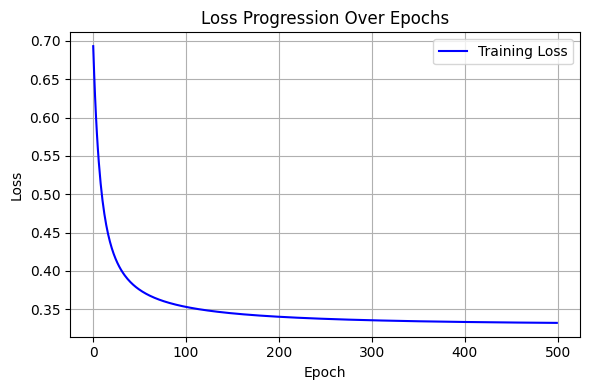

[INFO] Loss plot saved as 'training_loss.png'

[INFO] Training complete.
[INFO] Best final loss: 0.33222
[INFO] Learned weights: [-0.148  0.66   0.449  0.369  0.476 -0.237  0.276 -0.612  0.632 -0.124
  0.383  1.172  0.77 ]
[INFO] Bias: -0.152


In [16]:

# --- Basic Logistic Regression with Early Stopping & Loss Logging ---

def sigmoid(z):
    z = np.clip(z, -50, 50)
    return 1.0 / (1.0 + np.exp(-z))

def compute_loss(y_true, y_prob):
    eps = 1e-9
    return -np.mean(y_true * np.log(y_prob + eps) + (1 - y_true) * np.log(1 - y_prob + eps))

def train_logistic_regression(
    X, y, lr=0.1, steps=500, patience=5, plot_path="training_loss.png"
):
    """
    Train logistic regression with early stopping based on loss.
    - patience: number of epochs without improvement before stopping
    """
    n, d = X.shape
    w = np.zeros(d)
    b = 0.0
    best_loss = float("inf")
    epochs_no_improve = 0
    loss_log = []

    for i in range(steps):
        z = X @ w + b
        y_hat = sigmoid(z)

        loss = compute_loss(y, y_hat)
        loss_log.append(loss)

        # Gradients
        grad_w = (X.T @ (y_hat - y)) / n
        grad_b = (y_hat - y).mean()

        # Parameter updates
        w -= lr * grad_w
        b -= lr * grad_b

        # Early stopping check
        if loss < best_loss - 1e-5:
            best_loss = loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if i % 50 == 0 or i == steps - 1:
            print(f"Step {i:03d}: loss = {loss:.5f}")

        if epochs_no_improve >= patience:
            print(f"\n[Early Stopping] No improvement for {patience} epochs at step {i}.")
            break

    # Plot loss progression
    plt.figure(figsize=(6, 4))
    plt.plot(loss_log, label="Training Loss", color="blue")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Progression Over Epochs")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_path, dpi=120)
    plt.show()

    print(f"[INFO] Loss plot saved as '{plot_path}'")
    return w, b, loss_log

# ---- Train model ----
w, b, loss_log = train_logistic_regression(
    X_train_std, y_train, lr=0.1, steps=500, patience=5, plot_path="training_loss.png"
)

print("\n[INFO] Training complete.")
print("[INFO] Best final loss:", round(min(loss_log), 5))
print("[INFO] Learned weights:", np.round(w, 3))
print("[INFO] Bias:", round(b, 3))


## THIS CELL BELOW WILL SAVE YOUR OWN  VALUES FOR ACTUALY HOMEWORK:

In [17]:
# --- Save weights, bias, and test data for evaluation notebook ---

np.save("weights_student.npy", w)
np.save("bias_student.npy", b)
np.save("X_test_student.npy", X_test_std)
np.save("y_test_student.npy", y_test)

print("[SAVED] Model weights and test data for evaluation notebook:")
print("  weights_student.npy")
print("  bias_student.npy")
print("  X_test_student.npy")
print("  y_test_student.npy")


[SAVED] Model weights and test data for evaluation notebook:
  weights_student.npy
  bias_student.npy
  X_test_student.npy
  y_test_student.npy
